### Preparation

#### Imports 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle

#### Creating the dataset

In [2]:

def generate_data(sigma, n_samples_per_class,silent=False): 
    cov = [[sigma, 0], [0, sigma]]  
    # Class -1
    mu1 = [-1, 0]
    X1 = np.random.multivariate_normal(mu1, cov, n_samples_per_class)
    y1 = -1 * np.ones(n_samples_per_class)

    # Class 0
    mu2 = [1, 0]
    X2 = np.random.multivariate_normal(mu2, cov, n_samples_per_class)
    y2 = np.zeros(n_samples_per_class)   

    X = np.vstack((X1, X2))
    y = np.hstack((y1, y2))
    X, y = shuffle(X, y, random_state=42)

    # Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    if not silent:
        print(f"Train : X={X_train.shape}, y={y_train.shape}")
        print(f"Test  : X={X_test.shape}, y={y_test.shape}")
    
    return X_train, X_test, y_train, y_test

#### visualizing the data 

In [3]:
def visualize_data(X, y,sigma):
    plt.figure(figsize=(10, 6))
    # Plot Class -1
    plt.scatter(X[y == -1][:, 0], X[y == -1][:, 1], 
                color='red', marker='^', label='Class -1')

    # Plot Class 0
    plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], 
                color='blue', marker='s', label='Class 0')

    plt.title(f'Data  (Sigma^2 = {sigma})')
    plt.xlabel('Feature 1 ($x_1$)')
    plt.ylabel('Feature 2 ($x_2$)')
    plt.axvline(0, color='black', linestyle='--', alpha=0.3)
    plt.axhline(0, color='black', linestyle='--', alpha=0.3)
    plt.legend()
    plt.grid(True)
    plt.show()

#### Activation function

In [4]:
def acti_func(z):
    return 1 if z > 0 else 0

#### Perceptron algo

In [5]:
def perceptron(X, y, lr, epochs):
    m, n = X.shape
    
    
    w = np.zeros((n + 1, 1))
    n_miss_list = []
    
    for epoch in range(epochs):
        n_miss = 0
        
        for idx, x_i in enumerate(X):
       
            x_i_bias = np.insert(x_i, 0, 1).reshape(-1, 1)
            
           
            z = np.dot(w.T, x_i_bias)
            y_hat = acti_func(z)
            
            target = 0 if y[idx] == -1 else 1
            
            error = target - y_hat
            
            if error != 0:
                # Update 
                w += lr * error * x_i_bias
                n_miss += 1
                
        n_miss_list.append(n_miss)
        
    return w, n_miss_list

#### Decision boundry function

In [6]:
def plot_decision_boundary(X, y, w, title="Decision Boundary"):
    plt.figure(figsize=(10, 6))
    
    #  Plot data 
    plt.scatter(X[y == -1][:, 0], X[y == -1][:, 1], color='red', marker='^', label='Class -1')
    plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='blue', marker='s', label='Class 0')
    
    # Calculate
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x1_vals = np.array([x1_min, x1_max])
    x2_vals = -(w[1] * x1_vals + w[0]) / w[2]


    #  Plot  
    plt.plot(x1_vals, x2_vals, 'g-', linewidth=2, label="Decision Boundary")
    plt.ylim(-2, 2) 
    plt.xlim(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5)

    plt.title(title)
    plt.xlabel('Feature 1 ($x_1$)')
    plt.ylabel('Feature 2 ($x_2$)')
    plt.legend()
    plt.grid(True)
    plt.show()


#### Function to calculate accuracy

In [7]:
def calculate_accuracy(X, y, w):
    correct = 0
    count = 0
    for idx, x_i in enumerate(X):
        x_i_bias = np.insert(x_i, 0, 1).reshape(-1, 1)
        z = np.dot(w.T, x_i_bias)
        y_hat = acti_func(z)
        
        target = 0 if y[idx] == -1 else 1
        
        if y_hat == target:
            correct += 1
        count += 1
    return correct / count

#### Experiment function

In [8]:
def run_experiment(number,sigma, n, lr, epochs):

    # data 
    X_train_i, X_test_i, y_train_i, y_test_i = generate_data(sigma, n)
    print("\n \n visualizing data")
    visualize_data(X_train_i, y_train_i, sigma)

    # train
    print("\n \n training and visualizing")
    w_i, errors = perceptron(X_train_i, y_train_i, lr, epochs)
    print(f"Weights:\n{w_i}")
    print(f"Errors per epoch: {errors}")
    plot_decision_boundary(X_train_i, y_train_i, w_i, title=f"Exp {number}: Training Set Results")

    # test
    print("\n \n testing and evaluating")
    accuracy_i = calculate_accuracy(X_test_i, y_test_i, w_i)
    print(f"Accuracy on Test: {accuracy_i * 100:.2f}%")
    plot_decision_boundary(X_test_i, y_test_i, w_i, title=f"Exp {number}: Test Results (Accuracy: {accuracy_i:.2%})")



In [9]:
def run_silent_experiment(sigma, n, lr, epochs):

    # Data
    X_train, X_test, y_train, y_test = generate_data(sigma, n, silent=True)
    
    # Train
    w, _ = perceptron(X_train, y_train, lr, epochs)
    
    # Test
    acc = calculate_accuracy(X_test, y_test, w)
    error = 1.0 - acc
    
    return error

### Experiment 1

Train : X=(200, 2), y=(200,)
Test  : X=(50, 2), y=(50,)

 
 visualizing data


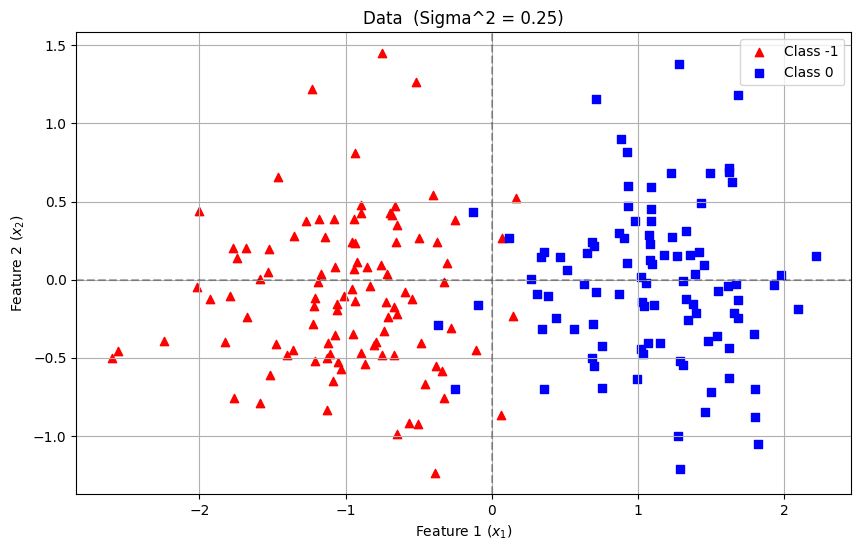


 
 training and visualizing
Weights:
[[0.        ]
 [0.02918795]
 [0.00021452]]
Errors per epoch: [14, 12, 12, 12, 12]


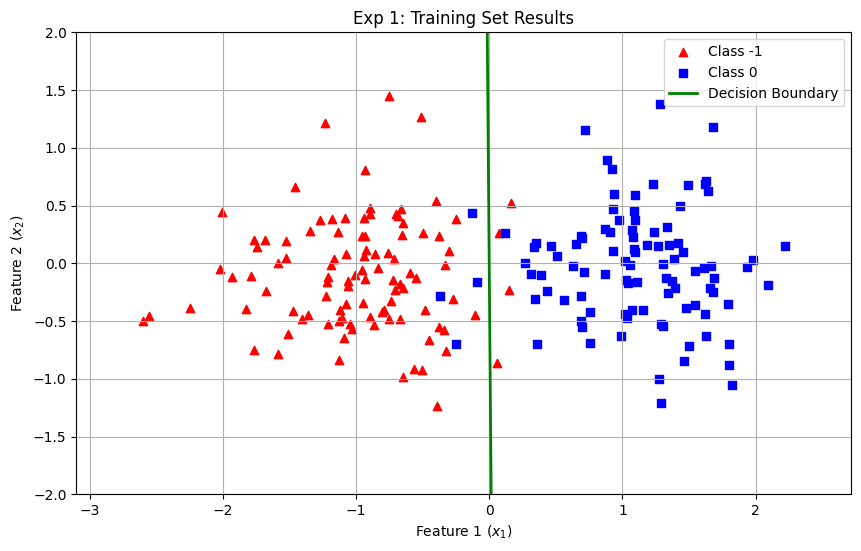


 
 testing and evaluating
Accuracy on Test: 96.00%


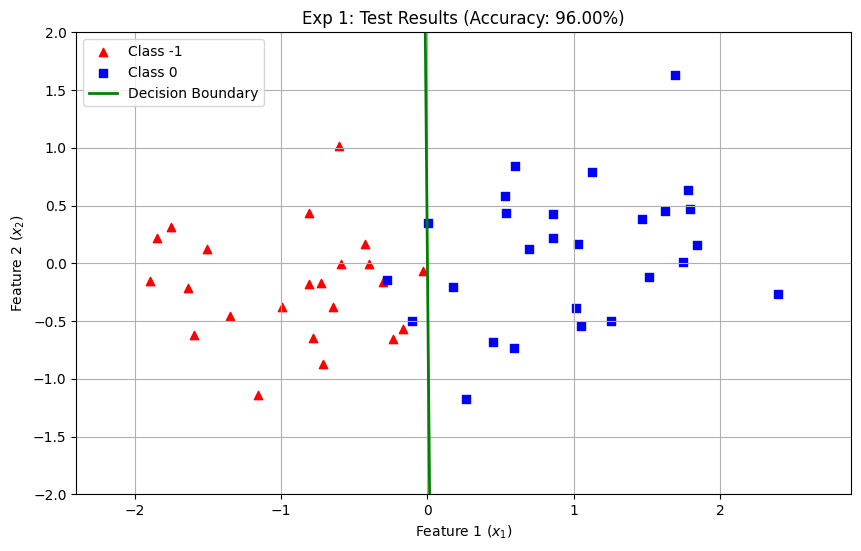

In [10]:
sigma_1 = 0.25
n_1 = 125
lr_1=0.01
epochs_1 = 5


run_experiment(1,sigma_1, n_1, lr_1, epochs_1)

### Experiment 2

Train : X=(200, 2), y=(200,)
Test  : X=(50, 2), y=(50,)

 
 visualizing data


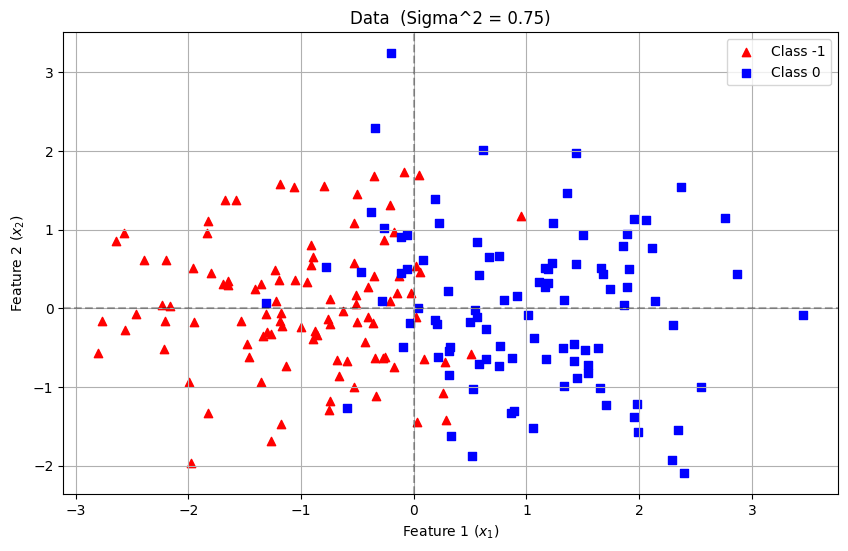


 
 training and visualizing
Weights:
[[ 0.        ]
 [ 0.02566985]
 [-0.00081798]]
Errors per epoch: [34, 36, 34, 38, 36]


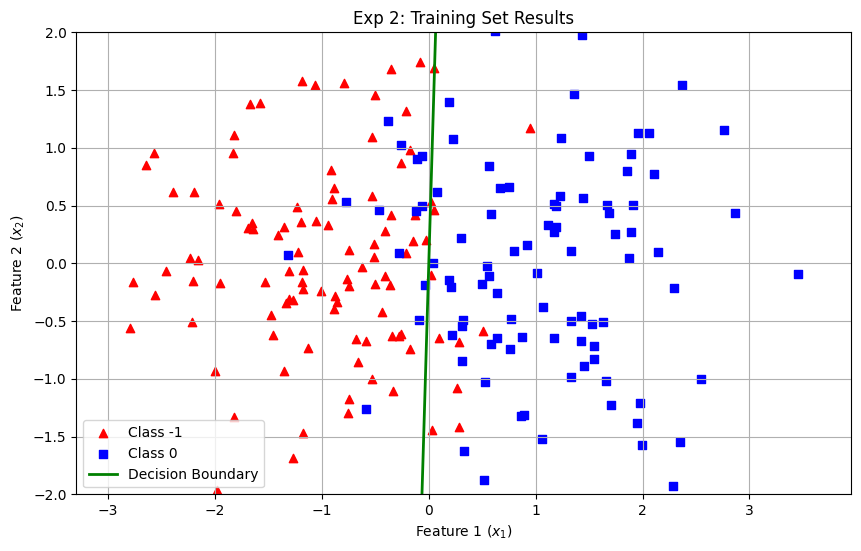


 
 testing and evaluating
Accuracy on Test: 90.00%


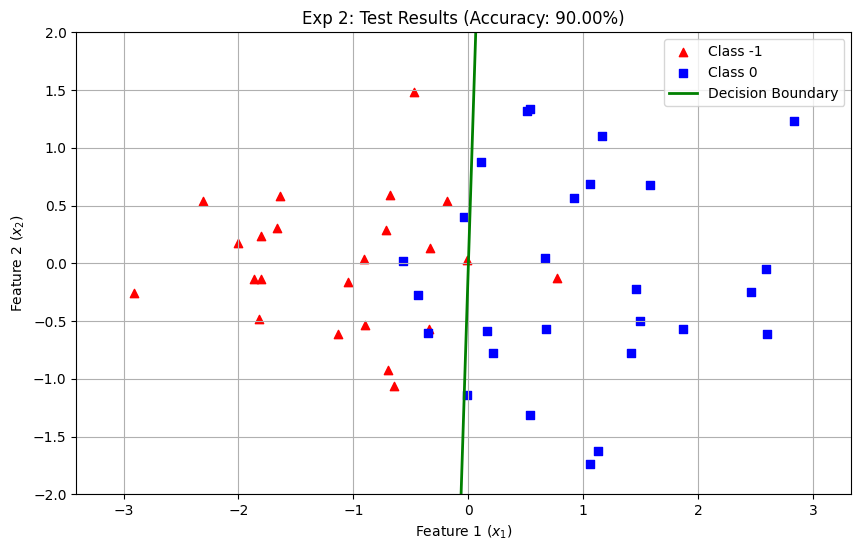

In [11]:
sigma_2 = 0.75
n_2 = 125
lr_2=0.01
epochs_2 = 5

run_experiment(2,sigma_2, n_2, lr_2, epochs_2)


### Experiment 3

#### Exp function

In [12]:
def run_experiment_3(sigmas, nb_exp, n, LR, EPOCHS):
    means = []
    variances = []

    for sigma in sigmas:
        errors = []
        
        # Repeat exp
        for i in range(nb_exp):
            err = run_silent_experiment(sigma, n, LR, EPOCHS)
            errors.append(err)
        
        # mean and var
        mean_err = np.mean(errors)
        var_err = np.var(errors)
        
        means.append(mean_err)
        variances.append(var_err)
        
        print(f"Sigma: {sigma} | Mean: {mean_err:.4f} | Variance: {var_err:.4f}")

    return means, variances

#### Visulization function

In [13]:
def visualize_experiment_3(sigmas, means, variances):

    plt.figure(figsize=(10, 6))
    std_devs = np.sqrt(variances)

    plt.errorbar(sigmas, means, yerr=std_devs, fmt='-o', ecolor='red', capsize=5, label='Mean Error')

    plt.title("Impact of Variance (sigma^2)")
    plt.xlabel("Variance ($\sigma^2$)")
    plt.ylabel("Test Error")
    plt.xticks(sigmas) 
    plt.grid(True)
    plt.legend()
    plt.show()

#### Implementation

Sigma: 0.01 | Mean: 0.0000 | Variance: 0.0000
Sigma: 0.1 | Mean: 0.0027 | Variance: 0.0000
Sigma: 0.25 | Mean: 0.0373 | Variance: 0.0006
Sigma: 0.5 | Mean: 0.1220 | Variance: 0.0092
Sigma: 0.7 | Mean: 0.1493 | Variance: 0.0025
[0.0, 0.002666666666666669, 0.03733333333333335, 0.12200000000000004, 0.14933333333333335] [0.0, 4.6222222222222326e-05, 0.0006328888888888888, 0.00920933333333333, 0.0025262222222222222]


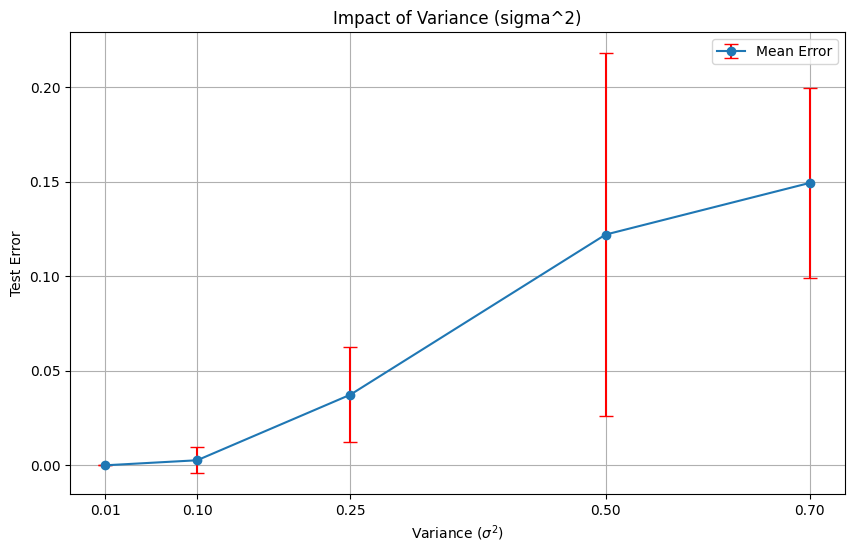

In [14]:
# init
sigmas = [0.01, 0.1, 0.25, 0.5, 0.7]
nb_exp = 30
n = 125
LR = 0.01
EPOCHS = 5

# experiment
means , variances = run_experiment_3(sigmas, nb_exp, n, LR, EPOCHS)

print(means, variances)

# error bars
visualize_experiment_3(sigmas, means, variances)

#### Comment

Augmentation de la variance sigma²


==> Chevauchement des classes


==> perte de separation lineaire 


==> Augmentation de l'erreur